In [ ]:
!pip install -q langchain-text-splitters sentence-transformers tiktoken

In [ ]:
sample_document = """# Auto Insurance Policy — Section 4: Coverage Details

## 4.1 Collision Coverage
The Company will pay for direct and accidental physical loss to your covered auto caused by
collision, subject to a $500 deductible per occurrence. This coverage applies regardless of
fault. Collision coverage does not apply to mechanical breakdown or normal wear and tear.

## 4.2 Comprehensive Coverage
The Company will pay for direct and accidental physical loss to your covered auto not caused
by collision, including but not limited to fire, theft, vandalism, and falling objects. A
$250 deductible applies per occurrence.

## 4.3 Rental Reimbursement
If your covered auto is out of service due to a covered collision or comprehensive loss, the
Company will reimburse rental costs up to $40 per day for a maximum of 30 days. Rental
reimbursement does not apply to losses covered under Section 4.5 (Roadside Assistance).

## 4.4 Exclusions
The following are excluded from coverage under this section:
- Damage from racing or speed contests
- Damage while the vehicle is used for commercial delivery services
- Damage occurring outside the policy territory
- Wear, tear, freezing, or mechanical breakdown

## 4.5 Roadside Assistance
The Company will reimburse reasonable towing and labor costs up to $100 per disablement,
limited to four disablements per policy period. Roadside assistance is a separate benefit
from rental reimbursement and does not require a collision or comprehensive claim.
"""

print(f"Document length: {len(sample_document)} characters, "
      f"{len(sample_document.split())} words, "
      f"{sample_document.count(chr(10)+chr(10))} paragraph breaks.")

Document length: 1479 characters, 232 words, 5 paragraph breaks.


In [ ]:
def fixed_size_chunks(text, chunk_size=200):
    return [text[i:i + chunk_size] for i in range(0, len(text), chunk_size)]

chunks_fixed = fixed_size_chunks(sample_document, chunk_size=200)

print(f"Produced {len(chunks_fixed)} chunks\n")
for i, c in enumerate(chunks_fixed[:4]):
    print(f"--- Chunk {i+1} ({len(c)} chars) ---")
    print(c)
    print()

Produced 8 chunks

--- Chunk 1 (200 chars) ---
# Auto Insurance Policy — Section 4: Coverage Details

## 4.1 Collision Coverage
The Company will pay for direct and accidental physical loss to your covered auto caused by
collision, subject to a $50

--- Chunk 2 (200 chars) ---
0 deductible per occurrence. This coverage applies regardless of
fault. Collision coverage does not apply to mechanical breakdown or normal wear and tear.

## 4.2 Comprehensive Coverage
The Company wi

--- Chunk 3 (200 chars) ---
ll pay for direct and accidental physical loss to your covered auto not caused
by collision, including but not limited to fire, theft, vandalism, and falling objects. A
$250 deductible applies per occ

--- Chunk 4 (200 chars) ---
urrence.

## 4.3 Rental Reimbursement
If your covered auto is out of service due to a covered collision or comprehensive loss, the
Company will reimburse rental costs up to $40 per day for a maximum o



In [ ]:
import re

def sentence_chunks(text, sentences_per_chunk=3):
    # Naive sentence splitter (good enough for a demo; use a real NLP library in production)
    clean = re.sub(r"\n+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", clean)
    sentences = [s.strip() for s in sentences if s.strip()]
    return [" ".join(sentences[i:i + sentences_per_chunk])
            for i in range(0, len(sentences), sentences_per_chunk)]

chunks_sentence = sentence_chunks(sample_document, sentences_per_chunk=3)

print(f"Produced {len(chunks_sentence)} chunks\n")
for i, c in enumerate(chunks_sentence[:4]):
    print(f"--- Chunk {i+1} ({len(c)} chars) ---")
    print(c)
    print()

Produced 3 chunks

--- Chunk 1 (353 chars) ---
# Auto Insurance Policy — Section 4: Coverage Details ## 4.1 Collision Coverage The Company will pay for direct and accidental physical loss to your covered auto caused by collision, subject to a $500 deductible per occurrence. This coverage applies regardless of fault. Collision coverage does not apply to mechanical breakdown or normal wear and tear.

--- Chunk 2 (453 chars) ---
## 4.2 Comprehensive Coverage The Company will pay for direct and accidental physical loss to your covered auto not caused by collision, including but not limited to fire, theft, vandalism, and falling objects. A $250 deductible applies per occurrence. ## 4.3 Rental Reimbursement If your covered auto is out of service due to a covered collision or comprehensive loss, the Company will reimburse rental costs up to $40 per day for a maximum of 30 days.

--- Chunk 3 (665 chars) ---
Rental reimbursement does not apply to losses covered under Section 4.5 (Roadside Assis

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""],
)
chunks_recursive = splitter.split_text(sample_document)

print(f"Produced {len(chunks_recursive)} chunks\n")
for i, c in enumerate(chunks_recursive):
    print(f"--- Chunk {i+1} ({len(c)} chars) ---")
    print(c)
    print()

Produced 7 chunks

--- Chunk 1 (53 chars) ---
# Auto Insurance Policy — Section 4: Coverage Details

--- Chunk 2 (209 chars) ---
## 4.1 Collision Coverage
The Company will pay for direct and accidental physical loss to your covered auto caused by
collision, subject to a $500 deductible per occurrence. This coverage applies regardless of

--- Chunk 3 (89 chars) ---
fault. Collision coverage does not apply to mechanical breakdown or normal wear and tear.

--- Chunk 4 (252 chars) ---
## 4.2 Comprehensive Coverage
The Company will pay for direct and accidental physical loss to your covered auto not caused
by collision, including but not limited to fire, theft, vandalism, and falling objects. A
$250 deductible applies per occurrence.

--- Chunk 5 (295 chars) ---
## 4.3 Rental Reimbursement
If your covered auto is out of service due to a covered collision or comprehensive loss, the
Company will reimburse rental costs up to $40 per day for a maximum of 30 days. Rental
reimbursement does not a

In [ ]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

headers_to_split_on = [("##", "section")]
md_splitter = MarkdownHeaderTextSplitter(headers_to_split_on=headers_to_split_on)
structure_chunks = md_splitter.split_text(sample_document)

print(f"Produced {len(structure_chunks)} chunks\n")
for i, doc in enumerate(structure_chunks):
    print(f"--- Chunk {i+1} | metadata: {doc.metadata} ({len(doc.page_content)} chars) ---")
    print(doc.page_content.strip())
    print()

Produced 6 chunks

--- Chunk 1 | metadata: {} (53 chars) ---
# Auto Insurance Policy — Section 4: Coverage Details

--- Chunk 2 | metadata: {'section': '4.1 Collision Coverage'} (273 chars) ---
The Company will pay for direct and accidental physical loss to your covered auto caused by
collision, subject to a $500 deductible per occurrence. This coverage applies regardless of
fault. Collision coverage does not apply to mechanical breakdown or normal wear and tear.

--- Chunk 3 | metadata: {'section': '4.2 Comprehensive Coverage'} (222 chars) ---
The Company will pay for direct and accidental physical loss to your covered auto not caused
by collision, including but not limited to fire, theft, vandalism, and falling objects. A
$250 deductible applies per occurrence.

--- Chunk 4 | metadata: {'section': '4.3 Rental Reimbursement'} (267 chars) ---
If your covered auto is out of service due to a covered collision or comprehensive loss, the
Company will reimburse rental costs up to $40 per da

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import re

embedder = SentenceTransformer("all-MiniLM-L6-v2")

def semantic_chunks(text, similarity_drop_threshold=0.25):
    clean = re.sub(r"\n+", " ", text).strip()
    clean = re.sub(r"#+\s*", "", clean)  # strip markdown heading markers for this demo
    sentences = re.split(r"(?<=[.!?])\s+", clean)
    sentences = [s.strip() for s in sentences if s.strip()]

    embeddings = embedder.encode(sentences, normalize_embeddings=True)

    # cosine similarity between each sentence and the next
    sims = [float(np.dot(embeddings[i], embeddings[i + 1])) for i in range(len(embeddings) - 1)]

    chunks, current = [], [sentences[0]]
    for i, sim in enumerate(sims):
        if sim < (1 - similarity_drop_threshold):
            chunks.append(" ".join(current))
            current = [sentences[i + 1]]
        else:
            current.append(sentences[i + 1])
    chunks.append(" ".join(current))
    return chunks, sims

chunks_semantic, similarities = semantic_chunks(sample_document)

print(f"Produced {len(chunks_semantic)} chunks\n")
for i, c in enumerate(chunks_semantic):
    print(f"--- Chunk {i+1} ({len(c)} chars) ---")
    print(c)
    print()

print("Sentence-to-sentence similarity scores (a big drop = a chunk boundary):")
print([round(s, 2) for s in similarities])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Produced 9 chunks

--- Chunk 1 (222 chars) ---
Auto Insurance Policy — Section 4: Coverage Details 4.1 Collision Coverage The Company will pay for direct and accidental physical loss to your covered auto caused by collision, subject to a $500 deductible per occurrence.

--- Chunk 2 (42 chars) ---
This coverage applies regardless of fault.

--- Chunk 3 (82 chars) ---
Collision coverage does not apply to mechanical breakdown or normal wear and tear.

--- Chunk 4 (207 chars) ---
4.2 Comprehensive Coverage The Company will pay for direct and accidental physical loss to your covered auto not caused by collision, including but not limited to fire, theft, vandalism, and falling objects.

--- Chunk 5 (41 chars) ---
A $250 deductible applies per occurrence.

--- Chunk 6 (197 chars) ---
4.3 Rental Reimbursement If your covered auto is out of service due to a covered collision or comprehensive loss, the Company will reimburse rental costs up to $40 per day for a maximum of 30 days.

--- Chunk 7 (

In [ ]:
import statistics

strategies = {
    "Fixed-Size (200 chars)": chunks_fixed,
    "Sentence-Based (3/chunk)": chunks_sentence,
    "Recursive + Overlap": chunks_recursive,
    "Structure-Aware (by heading)": [d.page_content for d in structure_chunks],
    "Semantic": chunks_semantic,
}

print(f"{'Strategy':<32}{'# Chunks':<10}{'Avg Len':<10}{'Min Len':<10}{'Max Len':<10}")
for name, chunks in strategies.items():
    lengths = [len(c) for c in chunks]
    print(f"{name:<32}{len(chunks):<10}{int(statistics.mean(lengths)):<10}{min(lengths):<10}{max(lengths):<10}")

Strategy                        # Chunks  Avg Len   Min Len   Max Len   
Fixed-Size (200 chars)          8         184       79        200       
Sentence-Based (3/chunk)        3         490       353       665       
Recursive + Overlap             7         209       53        295       
Structure-Aware (by heading)    6         223       53        273       
Semantic                        9         160       41        439       


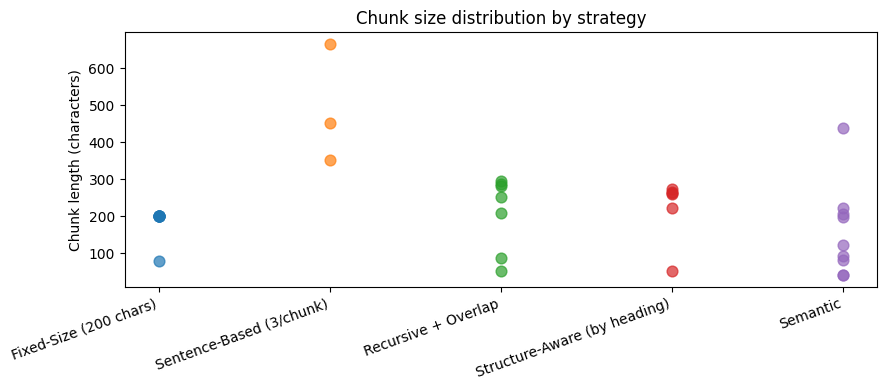

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
for name, chunks in strategies.items():
    lengths = [len(c) for c in chunks]
    ax.scatter([name] * len(lengths), lengths, alpha=0.7, s=60)

ax.set_ylabel("Chunk length (characters)")
ax.set_title("Chunk size distribution by strategy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import os
from langchain_text_splitters import RecursiveCharacterTextSplitter

sample_document = """# Auto Insurance Policy — Section 4: Coverage Details

## 4.1 Collision Coverage
The Company will pay for direct and accidental physical loss to your covered auto caused by
collision, subject to a $500 deductible per occurrence. This coverage applies regardless of
fault. Collision coverage does not apply to mechanical breakdown or normal wear and tear.

## 4.2 Comprehensive Coverage
The Company will pay for direct and accidental physical loss to your covered auto not caused
by collision, including but not limited to fire, theft, vandalism, and falling objects. A
$250 deductible applies per occurrence.

## 4.3 Rental Reimbursement
If your covered auto is out of service due to a covered collision or comprehensive loss, the
Company will reimburse rental costs up to $40 per day for a maximum of 30 days. Rental
reimbursement does not apply to losses covered under Section 4.5 (Roadside Assistance).

## 4.4 Exclusions
The following are excluded from coverage under this section:
- Damage from racing or speed contests
- Damage while the vehicle is used for commercial delivery services
- Damage occurring outside the policy territory
- Wear, tear, freezing, or mechanical breakdown

## 4.5 Roadside Assistance
The Company will reimburse reasonable towing and labor costs up to $100 per disablement,
limited to four disablements per policy period. Roadside assistance is a separate benefit
from rental reimbursement and does not require a collision or comprehensive claim.
"""

test_matrix = [
    {"chunk_size": 100, "chunk_overlap": 0},
    {"chunk_size": 100, "chunk_overlap": 50},
    {"chunk_size": 300, "chunk_overlap": 0},
    {"chunk_size": 300, "chunk_overlap": 50},
    {"chunk_size": 300, "chunk_overlap": 150},
    {"chunk_size": 600, "chunk_overlap": 0},
    {"chunk_size": 600, "chunk_overlap": 50},
    {"chunk_size": 600, "chunk_overlap": 150},
]

print(f"{'Chunk Size':<12}{'Overlap':<10}{'Total Chunks':<15}{'First Chunk Sneak Peek'}")
print("-" * 80)

for config in test_matrix:
    size = config["chunk_size"]
    overlap = config["chunk_overlap"]

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=size,
        chunk_overlap=overlap,
        separators=["\n\n", "\n", ". ", " ", ""] # Hierarchy: Paragraphs -> Lines -> Sentences -> Words -> Chars
    )

    chunks = splitter.split_text(sample_document)

    first_chunk_preview = chunks[0].replace('\n', ' ')[:45] if chunks else "N/A"

    print(f"{size:<12}{overlap:<10}{len(chunks):<15}\"{first_chunk_preview}...\"")

print("\n" + "="*30 + " DEEP INSPECTION: Size 300, Overlap 50 " + "="*30)
target_splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50, separators=["\n\n", "\n", ". ", " ", ""])
selected_chunks = target_splitter.split_text(sample_document)

for idx, chunk in enumerate(selected_chunks):
    print(f"\n--- Chunk {idx + 1} ({len(chunk)} characters) ---")
    print(chunk.strip())


Chunk Size  Overlap   Total Chunks   First Chunk Sneak Peek
--------------------------------------------------------------------------------
100         0         21             "# Auto Insurance Policy — Section 4: Coverage..."
100         50        21             "# Auto Insurance Policy — Section 4: Coverage..."
300         0         7              "# Auto Insurance Policy — Section 4: Coverage..."
300         50        7              "# Auto Insurance Policy — Section 4: Coverage..."
300         150       7              "# Auto Insurance Policy — Section 4: Coverage..."
600         0         3              "# Auto Insurance Policy — Section 4: Coverage..."
600         50        3              "# Auto Insurance Policy — Section 4: Coverage..."
600         150       3              "# Auto Insurance Policy — Section 4: Coverage..."

============================== DEEP INSPECTION: Size 300, Overlap 50 ==============================

--- Chunk 1 (53 characters) ---
# Auto Insurance Poli